## Creación de Prediction Pipeline

### By: Carlos Javier Palacios Sanchez

### Date: 07/09/2026

### Description:

Requerimiento
Crear un script en Python llamado `inference_pipeline.py` que:

- Cargue el modelo entrenado desde el almacenamiento del proyecto.
- Lea datos nuevos desde un archivo.
- Aplique las mismas transformaciones usadas durante entrenamiento.
- Genere y almacene o visualice las predicciones.

El script debe poder ejecutarse de forma autónoma.

Puede utilizar como ejemplo:
https://github.com/JoseRZapata/air-quality-fti/blob/main/src/pipelines/inference_pipeline/inference-pipeline.py

Entregables:

- Script `inference_pipeline.py` funcional.
- Pruebas unitarias con un modelo dummy y datos sintéticos.
- Evidencia de carga de modelo, transformación y generación de predicciones.

---

## Solución

| Entregable | Ruta |
|---|---|
| Script | `src/pipelines/inference_pipeline/inference_pipeline.py` |
| Pruebas unitarias | `tests/pipelines/inference_pipeline/test_inference_pipeline.py` |

### La cadena completa

```
corazon.csv
    │  feature_pipeline.py    transformaciones deterministas + validación
    ▼
corazon_features.parquet
    │  train_pipeline.py      transformaciones ajustadas + modelo + validación
    ▼
modelo_corazon_completo.joblib
    │  inference_pipeline.py  ← este entregable
    ▼
predicciones_nuevas.csv
```

### La decisión que define este script

**Las transformaciones no se reimplementan.** Se importan del feature pipeline:
`sanear_dataset`, `codificar_categoricas`, `generar_atributos_clinicos`. Y las que
aprenden de los datos —imputación y escalado— ni siquiera se invocan aquí: viajan
dentro del `Pipeline` serializado, ya ajustadas con el conjunto de entrenamiento.

Reescribir la lógica de transformación en el script de inferencia es la forma más
rápida de introducir *training-serving skew*: dos implementaciones que nacen iguales
y divergen en cuanto alguien toca una y olvida la otra. El modelo empieza a recibir
en producción columnas que significan algo distinto de lo que aprendió, y nada falla
de forma visible — sólo empeoran las predicciones.

### Dos diferencias deliberadas con el entrenamiento

1. **No se elimina ninguna fila.** En entrenamiento se deduplica y se descartan las
   filas sin etiqueta. Aquí cada paciente que entra tiene que salir con su predicción
   y en la misma posición: perder una fila en silencio sería devolverle a un paciente
   el resultado de otro.
2. **No hay variable objetivo.** Los datos nuevos no traen `disease`; si el archivo la
   incluye, se ignora y se avisa en el log.

## 1. Configuración

In [1]:
import json
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display


def localizar_raiz() -> Path:
    """Sube por el árbol de directorios hasta encontrar el pyproject.toml."""
    actual = Path.cwd().resolve()
    for candidato in (actual, *actual.parents):
        if (candidato / "pyproject.toml").is_file():
            return candidato
    raise FileNotFoundError("No se encontró la raíz del proyecto")


RAIZ = localizar_raiz()
SCRIPT = RAIZ / "src" / "pipelines" / "inference_pipeline" / "inference_pipeline.py"
PRUEBAS = RAIZ / "tests" / "pipelines" / "inference_pipeline"

MODELO = RAIZ / "data" / "06_models" / "modelo_corazon_completo.joblib"
ENTRADA = RAIZ / "data" / "01_raw" / "pacientes_nuevos.csv"
PREDICCIONES = RAIZ / "data" / "07_model_output" / "predicciones_nuevas.csv"
RESUMEN = RAIZ / "data" / "08_reporting" / "resumen_inferencia.json"
FIGURA = RAIZ / "data" / "08_reporting" / "figuras" / "distribucion_predicciones.png"

sys.path.insert(0, str(RAIZ / "src"))

from pipelines.inference_pipeline import inference_pipeline as ip  # noqa: E402

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

print(f"Raíz del proyecto: {RAIZ}")
print(f"Script           : {SCRIPT.relative_to(RAIZ)}  (existe: {SCRIPT.is_file()})")
print(f"Modelo           : {MODELO.relative_to(RAIZ)}  (existe: {MODELO.is_file()})")

Raíz del proyecto: /mnt/c/Users/KATANA/Heart_project
Script           : src/pipelines/inference_pipeline/inference_pipeline.py  (existe: True)
Modelo           : data/06_models/modelo_corazon_completo.joblib  (existe: True)


## 2. Preparar los datos nuevos

En un despliegue real este archivo lo produciría el sistema del hospital. Para el
entregable se simula tomando 40 pacientes del dataset original **y quitándoles la
etiqueta**: son datos con la misma forma que los de entrenamiento, pero de los que el
script no sabe el diagnóstico.

La celda es idempotente: si el archivo ya existe, no lo vuelve a generar.

In [2]:
if not ENTRADA.is_file():
    crudo = pd.read_csv(RAIZ / "data" / "01_raw" / "corazon.csv", dtype=str)
    nuevos = crudo.drop(columns=["disease"]).sample(n=40, random_state=7).reset_index(drop=True)
    nuevos.to_csv(ENTRADA, index=False)
    print(f"Generado {ENTRADA.name} con {len(nuevos)} pacientes")
else:
    print(f"{ENTRADA.name} ya existe")

pacientes = pd.read_csv(ENTRADA, dtype=str)
print(f"\nDimensión: {pacientes.shape[0]} pacientes x {pacientes.shape[1]} columnas")
print(f"¿Trae la variable objetivo?: {'disease' in pacientes.columns}")
pacientes.head()

Generado pacientes_nuevos.csv con 40 pacientes

Dimensión: 40 pacientes x 13 columnas
¿Trae la variable objetivo?: False


,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal
0,71,Female,nontypical,160,302,0,normal,162,0,0.4,1,2.0,normal
1,58,Male,asymptomatic,128,216,0,left ventricular hypertrophy,131,1,2.2,2,3.0,reversable
2,65,Female,nonanginal,155,269,0,normal,148,0,0.8,1,0.0,normal
3,48,Male,nonanginal,124,255,1,normal,175,0,0.0,1,2.0,normal
4,57,Male,asymptomatic,165,289,1,left ventricular hypertrophy,124,0,1.0,2,3.0,reversable


## 3. Ejecución autónoma

Se invoca el script como proceso independiente y sin argumentos, que es el requisito
a demostrar. El log recorre las cuatro etapas del requerimiento.

In [3]:
ejecucion = subprocess.run(  # noqa: S603
    [sys.executable, str(SCRIPT)],
    capture_output=True,
    text=True,
    check=False,
)

print(ejecucion.stderr or ejecucion.stdout)
print(f"Código de salida: {ejecucion.returncode}")

22:43:11 | INFO     | === Inference pipeline: inicio ===
22:43:14 | INFO     | Modelo cargado desde /mnt/c/Users/KATANA/Heart_project/data/06_models/modelo_corazon_completo.joblib
22:43:14 | INFO     |   tipo: Pipeline | umbral: 0.31 | atributos esperados: 26
22:43:14 | INFO     |   entrenado el 2026-09-07T03:07:59+00:00 con gradient_boosting
22:43:14 | INFO     | Datos nuevos leídos desde /mnt/c/Users/KATANA/Heart_project/data/01_raw/pacientes_nuevos.csv -> 40 filas x 13 columnas
22:43:14 | INFO     | Saneamiento de tipos: 0 valores inválidos convertidos a NaN
22:43:15 | INFO     | [inferencia] esquema 'features_inferencia': OK
22:43:15 | INFO     | Features generados: 40 filas x 26 columnas
22:43:15 | INFO     | Columnas alineadas con el modelo: 26 atributos
22:43:16 | INFO     | Predicciones generadas con umbral 0.31: 23 enfermos, 17 sanos
22:43:16 | INFO     | Predicciones guardadas: /mnt/c/Users/KATANA/Heart_project/data/07_model_output/predicciones_nuevas.csv (40 filas)
22:43:19 

## 4. Evidencia 1: carga del modelo

El script carga el **artefacto completo**, no sólo el pipeline. La diferencia importa:
el artefacto trae el umbral calibrado en el entregable 11. Con el `.joblib` suelto
habría que asumir 0.5, que no es el umbral con el que se evaluó este modelo.

In [4]:
modelo = ip.cargar_modelo(MODELO)

print(f"Tipo               : {type(modelo.pipeline).__name__}")
print(f"Pasos del pipeline : {list(modelo.pipeline.named_steps)}")
print(f"Umbral calibrado   : {modelo.umbral:.2f}")
print(f"Atributos esperados: {len(modelo.atributos_esperados)}")
print()
print("Metadatos que viajan con el modelo:")
for clave in ("modelo", "generado_en", "semilla", "version_sklearn", "n_train"):
    if clave in modelo.metadatos:
        print(f"  {clave:<18} = {modelo.metadatos[clave]}")

Tipo               : Pipeline
Pasos del pipeline : ['imputador', 'escalador', 'modelo']
Umbral calibrado   : 0.31
Atributos esperados: 26

Metadatos que viajan con el modelo:
  modelo             = gradient_boosting
  generado_en        = 2026-09-07T03:07:59+00:00
  semilla            = 42
  version_sklearn    = 1.9.0
  n_train            = 384


Los tres pasos del pipeline serializado son la prueba de que la imputación y el
escalado viajan **dentro** del modelo, con los parámetros aprendidos del entrenamiento.
El script de inferencia nunca calcula una mediana ni una media: si lo hiciera, las
calcularía sobre estos 40 pacientes en vez de sobre los 384 del entrenamiento, y el
modelo recibiría valores en una escala distinta de la que aprendió.

## 5. Evidencia 2: transformación

Las mismas funciones del feature pipeline, aplicadas a datos sin etiqueta.

In [5]:
features = ip.transformar(pacientes)

print(f"Entrada : {pacientes.shape[0]} filas x {pacientes.shape[1]} columnas")
print(f"Features: {features.shape[0]} filas x {features.shape[1]} columnas")
print(f"\n¿Se conservó cada fila?: {len(features) == len(pacientes)}")
features.head()

Entrada : 40 filas x 13 columnas
Features: 40 filas x 26 columnas

¿Se conservó cada fila?: True


,age,rest_bp,chol,max_hr,old_peak,ca,fbs,sex,exang,slope,chest_pain_asymptomatic,chest_pain_nonanginal,chest_pain_nontypical,chest_pain_typical,rest_ecg_left_ventricular_hypertrophy,rest_ecg_normal,rest_ecg_st_t_wave_abnormality,thal_fixed,thal_normal,thal_reversable,fc_maxima_teorica,reserva_cardiaca,pct_fc_alcanzada,ratio_chol_edad,presion_x_chol,indice_riesgo_st
0,71.0,160.0,302.0,162.0,0.4,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,149.0,13.0,1.087248,4.253521,48.320,0.0
1,58.0,128.0,216.0,131.0,2.2,3.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,162.0,-31.0,0.808642,3.724138,27.648,2.2
2,65.0,155.0,269.0,148.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,155.0,-7.0,0.954839,4.138462,41.695,0.0
3,48.0,124.0,255.0,175.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,172.0,3.0,1.017442,5.312500,31.620,0.0
4,57.0,165.0,289.0,124.0,1.0,3.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,163.0,-39.0,0.760736,5.070175,47.685,1.0


In [6]:
alineadas = ip.alinear_columnas(features, modelo)

print("Comprobación de correspondencia con el entrenamiento:")
print(
    f"  columnas generadas == columnas del modelo: {list(alineadas.columns) == modelo.atributos_esperados}"
)
print(f"  número de atributos: {alineadas.shape[1]}")
print()
print("Esta comprobación es la que separa una predicción válida de una")
print("silenciosamente equivocada: si el orden no coincide, muchos estimadores")
print("predicen igual, pero interpretando el colesterol como si fuera la edad.")

Comprobación de correspondencia con el entrenamiento:
  columnas generadas == columnas del modelo: True
  número de atributos: 26

Esta comprobación es la que separa una predicción válida de una
silenciosamente equivocada: si el orden no coincide, muchos estimadores
predicen igual, pero interpretando el colesterol como si fuera la edad.


### Robustez ante datos corruptos

Los datos nuevos vienen del mundo real, así que llegarán con basura. El saneamiento
es el mismo que en entrenamiento: lo no interpretable pasa a faltante y el imputador
del modelo lo resuelve, en vez de reventar.

In [7]:
sucio = pacientes.head(3).copy()
sucio.loc[0, "age"] = "no_es_una_edad"
sucio.loc[1, "thal"] = "categoria_inventada"
sucio.loc[2, "chol"] = None

features_sucias = ip.transformar(sucio)
predicciones_sucias = ip.predecir(modelo, ip.alinear_columnas(features_sucias, modelo))

comparacion = pd.DataFrame(
    {
        "problema": ["edad no numérica", "thal fuera del catálogo", "colesterol ausente"],
        "age": features_sucias["age"].to_numpy(),
        "thal_normal": features_sucias["thal_normal"].to_numpy(),
        "chol": features_sucias["chol"].to_numpy(),
        "probabilidad": predicciones_sucias["probabilidad_enfermedad"].to_numpy(),
    }
)
comparacion

,problema,age,thal_normal,chol,probabilidad
0,edad no numérica,NaN,1.0,302.0,0.1565
1,thal fuera del catálogo,58.0,NaN,216.0,0.9564
2,colesterol ausente,65.0,1.0,NaN,0.0225


Las tres filas conservan su NaN donde el dato era inutilizable, y las tres reciben una
predicción. Ningún paciente se pierde por un campo mal escrito en el origen.

## 6. Evidencia 3: generación de predicciones

La salida no es sólo la etiqueta. Se devuelve también la probabilidad, porque una
decisión binaria pierde toda la información de confianza: 0.51 y 0.99 predicen lo
mismo y no significan lo mismo para quien tiene que actuar.

In [8]:
predicciones = pd.read_csv(PREDICCIONES, index_col="paciente")

print(f"Predicciones generadas: {len(predicciones)}")
print()
print(predicciones["diagnostico"].value_counts().to_string())
predicciones[
    ["age", "sex", "chest_pain", "thal", "probabilidad_enfermedad", "diagnostico", "nivel_riesgo"]
].head(10)

Predicciones generadas: 40

diagnostico
enfermo    23
sano       17


,age,sex,chest_pain,thal,probabilidad_enfermedad,diagnostico,nivel_riesgo
paciente,,,,,,,
0,71,Female,nontypical,normal,0.2660,sano,bajo
1,58,Male,asymptomatic,reversable,0.9847,enfermo,muy alto
2,65,Female,nonanginal,normal,0.0210,sano,muy bajo
3,48,Male,nonanginal,normal,0.2521,sano,bajo
4,57,Male,asymptomatic,reversable,0.9820,enfermo,muy alto
5,35,Male,asymptomatic,reversable,0.9357,enfermo,muy alto
6,58,Male,asymptomatic,reversable,0.9754,enfermo,muy alto
7,44,Male,asymptomatic,fixed,0.7307,enfermo,alto
8,74,Female,nontypical,normal,0.1754,sano,muy bajo


El CSV adjunta los datos originales de cada paciente junto a su resultado. Es una
decisión deliberada: quien lo reciba puede auditarlo por sí solo, sin cruzarlo con
otro archivo para saber a qué paciente corresponde cada probabilidad.

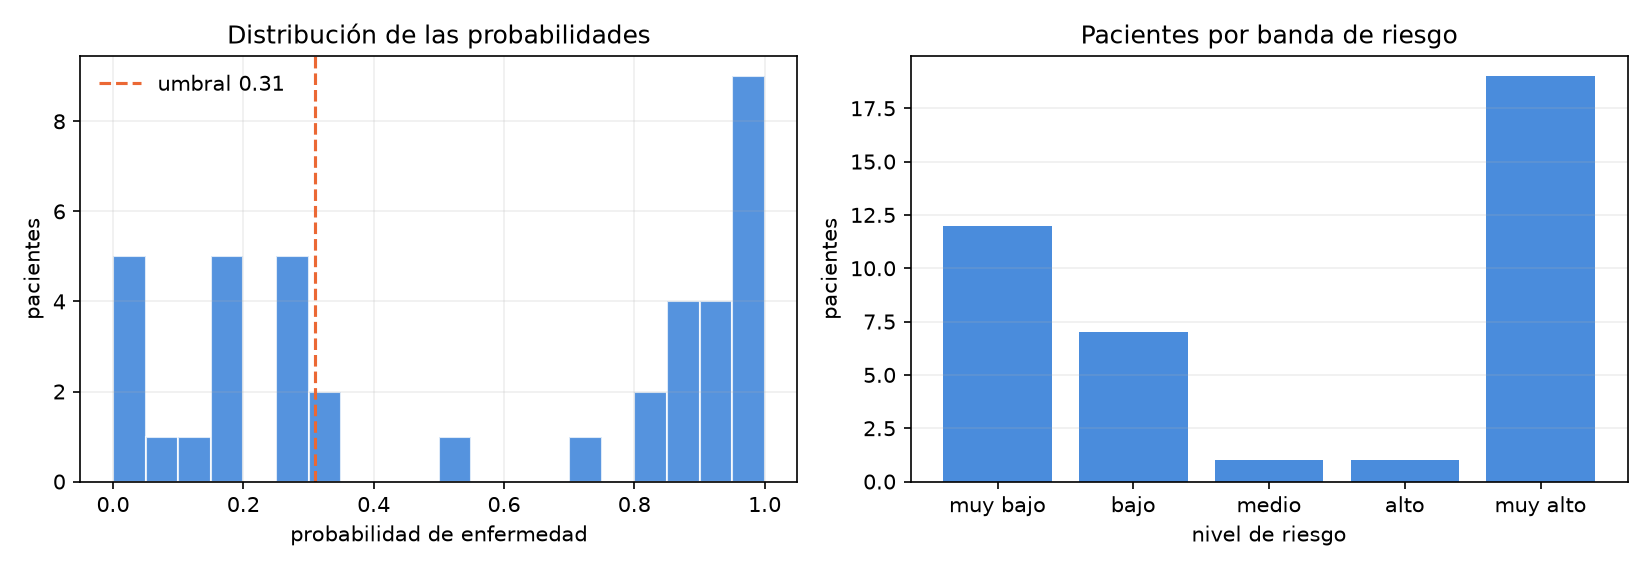

In [9]:
display(Image(filename=str(FIGURA)))

La visualización es la que más dice de un lote. Las probabilidades están polarizadas
—se agolpan cerca de 0 y de 1— y muy pocas caen junto al umbral. Eso significa que
el modelo está decidido en casi todos los casos y que mover un poco el umbral apenas
cambiaría el resultado.

El caso contrario también se lee de un vistazo: si el histograma se concentrara
alrededor del umbral, las decisiones serían frágiles y habría que revisarlas a mano.

In [10]:
resumen = json.loads(RESUMEN.read_text(encoding="utf-8"))

for clave, valor in resumen.items():
    print(f"  {clave:<24} = {valor}")

  generado_en              = 2026-09-07T03:43:19+00:00
  modelo                   = /mnt/c/Users/KATANA/Heart_project/data/06_models/modelo_corazon_completo.joblib
  modelo_entrenado_en      = 2026-09-07T03:07:59+00:00
  tipo_modelo              = gradient_boosting
  entrada                  = /mnt/c/Users/KATANA/Heart_project/data/01_raw/pacientes_nuevos.csv
  n_pacientes              = 40
  n_atributos              = 26
  umbral                   = 0.30999999999999994
  n_predichos_enfermos     = 23
  n_predichos_sanos        = 17
  probabilidad_media       = 0.5529
  por_nivel_riesgo         = {'muy alto': 19, 'muy bajo': 12, 'bajo': 7, 'alto': 1, 'medio': 1}
  faltantes_en_entrada     = 21


## 7. El umbral es un parámetro de la decisión, no del modelo

El mismo lote con distintos umbrales produce distintos diagnósticos, sin reentrenar
nada. Es la palanca para ajustar el balance entre no dejar pasar un enfermo y no
alarmar a un sano.

In [11]:
filas = []
for umbral in (0.20, modelo.umbral, 0.50, 0.80):
    resultado = ip.predecir(modelo, alineadas, umbral=umbral)
    filas.append(
        {
            "umbral": round(umbral, 2),
            "predichos enfermos": int(resultado["prediccion"].sum()),
            "predichos sanos": int(len(resultado) - resultado["prediccion"].sum()),
            "% enfermos": resultado["prediccion"].mean(),
        }
    )

tabla_umbrales = pd.DataFrame(filas).set_index("umbral")
tabla_umbrales.style.format({"% enfermos": "{:.1%}"})

,predichos enfermos,predichos sanos,% enfermos
umbral,,,
0.200000,28,12,70.0%
0.310000,23,17,57.5%
0.500000,21,19,52.5%
0.800000,19,21,47.5%


El umbral calibrado (0.31) es más permisivo que el 0.5 por convenio: prioriza la
sensibilidad, que es lo razonable en un tamizaje donde el falso negativo —un enfermo
que se va a casa— cuesta más que el falso positivo —una prueba adicional—.

## 8. Comportamiento ante fallos

Una predicción sobre datos que no encajan con lo que el modelo espera es **peor que
ninguna**, porque parece válida. Por eso los tres casos siguientes abortan en vez de
devolver números.

In [12]:
def probar(descripcion: str, accion) -> dict:
    """Ejecuta algo que debe fallar y captura el mensaje."""
    try:
        accion()
    except (ip.ErrorDeInferencia, FileNotFoundError) as error:
        primera_linea = str(error).splitlines()[0]
        return {"caso": descripcion, "detectado": "sí", "mensaje": primera_linea[:80]}
    return {"caso": descripcion, "detectado": "NO", "mensaje": "no saltó"}


sin_columna = ENTRADA.parent / "pacientes_incompletos.csv"
pacientes.drop(columns=["chol"]).to_csv(sin_columna, index=False)

casos = [
    probar(
        "el modelo no existe",
        lambda: ip.cargar_modelo(RAIZ / "data" / "06_models" / "no_existe.joblib"),
    ),
    probar(
        "al archivo de entrada le falta una columna",
        lambda: ip.leer_datos_nuevos(sin_columna),
    ),
    probar(
        "a los features les falta un atributo",
        lambda: ip.alinear_columnas(features.drop(columns=["age"]), modelo),
    ),
    probar(
        "los features traen una columna de más",
        lambda: ip.alinear_columnas(features.assign(columna_nueva=1.0), modelo),
    ),
]

pd.DataFrame(casos)

,caso,detectado,mensaje
0,el modelo no existe,sí,No se encuentra el modelo: /mnt/c/Users/KATANA...
1,al archivo de entrada le falta una columna,sí,Al archivo de entrada le faltan columnas oblig...
2,a los features les falta un atributo,sí,Las columnas generadas no coinciden con las de...
3,los features traen una columna de más,sí,Las columnas generadas no coinciden con las de...


## 9. Pruebas unitarias con modelo dummy y datos sintéticos

El entregable pide explícitamente que las pruebas usen un modelo dummy y datos
sintéticos, y hay una buena razón: si dependieran del `.joblib` real y del CSV real,
la suite fallaría en un clon recién descargado del repositorio, donde `data/` está en
el `.gitignore` y todavía no se ha entrenado nada.

El dummy es un `Pipeline` con los mismos pasos previos —imputación y escalado— y un
`DummyClassifier` en lugar del estimador de verdad. Interesa que **se comporte** como
el modelo real (que exponga `predict_proba` y `feature_names_in_`), no que prediga
bien: lo que se prueba es la mecánica de la inferencia, no la calidad del modelo.

In [13]:
pruebas = subprocess.run(  # noqa: S603
    [sys.executable, "-m", "pytest", str(PRUEBAS), "-v", "--no-header"],
    cwd=RAIZ,
    capture_output=True,
    text=True,
    check=False,
)

print(pruebas.stdout[-7000:])
print(f"Código de salida: {pruebas.returncode}")

============================= test session starts ==============================
collecting ... collected 42 items

tests/pipelines/inference_pipeline/test_inference_pipeline.py::test_carga_el_artefacto_completo_con_su_umbral PASSED [  2%]
tests/pipelines/inference_pipeline/test_inference_pipeline.py::test_carga_un_pipeline_suelto_con_umbral_por_defecto PASSED [  4%]
tests/pipelines/inference_pipeline/test_inference_pipeline.py::test_carga_expone_los_atributos_del_entrenamiento PASSED [  7%]
tests/pipelines/inference_pipeline/test_inference_pipeline.py::test_carga_falla_si_no_existe PASSED [  9%]
tests/pipelines/inference_pipeline/test_inference_pipeline.py::test_carga_rechaza_un_objeto_que_no_es_modelo PASSED [ 11%]
tests/pipelines/inference_pipeline/test_inference_pipeline.py::test_resolver_ruta_prefiere_el_artefacto_completo PASSED [ 14%]
tests/pipelines/inference_pipeline/test_inference_pipeline.py::test_lee_los_datos_como_texto PASSED [ 16%]
tests/pipelines/inference_pipeline/test

## 10. Conclusiones

| Requisito | Dónde se cumple |
|---|---|
| Carga el modelo entrenado | `cargar_modelo`, con umbral calibrado y metadatos |
| Lee datos nuevos desde un archivo | `leer_datos_nuevos`, con validación de esquema |
| Aplica las mismas transformaciones | funciones **importadas** del feature pipeline + pasos dentro del `Pipeline` serializado |
| Genera y almacena las predicciones | `predicciones_nuevas.csv` + `resumen_inferencia.json` |
| Visualiza las predicciones | `distribucion_predicciones.png` |
| Ejecución autónoma | sin argumentos, con código de salida 0/1 |
| Pruebas con modelo dummy y datos sintéticos | 42 pruebas que no dependen de `data/` |

Tres decisiones que vale la pena defender:

1. **Reutilizar, no reimplementar.** El riesgo real de un pipeline de inferencia no es
   que falle, es que funcione con una transformación ligeramente distinta a la del
   entrenamiento y nadie se entere. Importar las funciones en lugar de copiarlas hace
   que ese desfase sea imposible por construcción.

2. **Comprobar la correspondencia de columnas antes de predecir.** `alinear_columnas`
   verifica nombre y orden contra `feature_names_in_`. Sin esa comprobación, un cambio
   en el feature pipeline produciría predicciones plausibles y equivocadas.

3. **Ninguna fila se pierde.** El feature pipeline deduplica porque en entrenamiento
   las filas repetidas sesgan; en inferencia cada fila es un paciente esperando un
   resultado. La misma transformación con distinta política de filas, y la diferencia
   está documentada en el docstring del módulo para que nadie la "corrija" por error.